# Notes
[2026-06-05] - 
Created the loading in mechanism
[2026-06-08] - 
Created the first "working" model (extremely slow, though that may be due to its genormeous size)
[2026-06-09] - changed the masking to BART-inspired one, accuracy went from 10% &rarr; 20%. Furthermore, increasing the cutoff does not improve accuracy all that much

In [88]:
import pandas as pd
import numpy as np
import torch.nn.functional as F
from torch import nn
from Bio import SeqIO 
import torch
import random
from dataclasses import dataclass
from pathlib import Path

random.seed(42)
np.random.seed (42)

print ("imported")

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu" # when running locally with newer PyTorch versions with torch.accelerator support

# device = "cuda" if torch.cuda.is_available() else "cpu" # alternative for older PyTorch versions without torch.accelerator, for use on the cluster 

print(f"Using: {device} \n")

@dataclass
class ModelArgs:
    length_cutoff: int = 300
    masking_rate: float = 0.15
    batch_size=32
    src_vocab_size = 23
    tgt_vocab_size = 23
    d_model = 128
    num_heads = 8
    num_layers = 8
    d_ff = 4*d_model
    max_seq_length = 1000
    dropout = 0.1
    num_epochs=100
    learning_rate = 1e-3
    weight_decay = 1e-3


data_path = "./data/uniprotkb_taxonomy_id_1002366_2026_06_05.fasta"

imported
Using: mps 



My plan is to separate the file into a 

In [89]:
data_path = "./data/uniprotkb_taxonomy_id_1002366_2026_06_05.fasta"

sequences = [str(record.seq) for record in SeqIO.parse(data_path, "fasta")]
sequences = [seq for seq in sequences if len(seq) < ModelArgs.length_cutoff]

print("Number of sequences:", len(sequences))

Number of sequences: 1792


In [90]:
AminoAcids = sorted(list(set("".join(sequences))))  # X is a padding, - is masking
aa_vocab= ["X"]+ ["-"] + ["[CLS]"] + AminoAcids 
print(len(aa_vocab))
print(aa_vocab)

aa_stoi = {s: i for i, s in enumerate(aa_vocab)}
aa_itos = {i: s for i, s in enumerate(aa_vocab)}

pad_idx = aa_stoi["X"]
mask_idx = aa_stoi["-"]
cls_idx = aa_stoi["[CLS]"]

23
['X', '-', '[CLS]', 'A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y']


In [91]:
traindata, valdata, testdata = torch.utils.data.random_split(sequences, [0.80, 0.10, 0.10])

print(f"Train size: {len(traindata)}, Val size: {len(valdata)}, Test size: {len(testdata)} \n")

Train size: 1434, Val size: 179, Test size: 179 



In [92]:
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence
import torch
import torch.nn.functional as F

def make_masked(seq, mask_prob=0.15):
    masked = []
    labels = []

    for aa in seq:
        if torch.rand(1).item() < mask_prob:
            labels.append(aa_stoi[aa])

            r = torch.rand(1).item()

            if r < 0.8:
                masked.append("-")
            elif r < 0.9:
                masked.append(random.choice(list(AminoAcids)))
            else:
                masked.append(aa)
        else:
            masked.append(aa)
            labels.append(-100)

    return "".join(masked), torch.tensor(labels, dtype=torch.long)

def make_collate_fn(mask_rate):
    def collate_fn(batch):
        original = list(batch)

        masked_data = [make_masked(seq, mask_rate) for seq in original]

        masked = [item[0] for item in masked_data]
        y = [torch.cat([torch.tensor([-100], dtype=torch.long), item[1]]) for item in masked_data]

        x_ids = [torch.tensor([cls_idx] + [aa_stoi[aa] for aa in seq], dtype=torch.long) for seq in masked]

        lengths = torch.tensor([len(seq) for seq in x_ids], dtype=torch.long)

        x_ids = pad_sequence(x_ids, batch_first=True, padding_value=aa_stoi["X"])

        y = pad_sequence(y, batch_first=True, padding_value=-100)

        attention_mask = torch.arange(x_ids.shape[1]).unsqueeze(0) < lengths.unsqueeze(1)

        return x_ids, y, attention_mask

    return collate_fn

In [93]:
train_loader = DataLoader(traindata, batch_size=ModelArgs.batch_size, shuffle=True, collate_fn=make_collate_fn(ModelArgs.masking_rate))
val_loader = DataLoader(valdata, batch_size=ModelArgs.batch_size, shuffle=False, collate_fn=make_collate_fn(ModelArgs.masking_rate))
test_loader = DataLoader(testdata, batch_size=ModelArgs.batch_size, shuffle=False, collate_fn=make_collate_fn(ModelArgs.masking_rate))

In [94]:
import torch
import torch.nn as nn
import math
import copy

# Encoder-only architecture
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        
    def scaled_dot_product_attention(self, Q, K, V, mask=None, return_attention = False):
        attn_scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        if mask is not None:
            attn_scores = attn_scores.masked_fill(mask == 0, -1e9)
        attn_probs = torch.softmax(attn_scores, dim=-1)
        output = torch.matmul(attn_probs, V)
        if return_attention:
            return output, attn_probs
            
        return output
        
    def split_heads(self, x):
        batch_size, seq_length, d_model = x.size()
        return x.view(batch_size, seq_length, self.num_heads, self.d_k).transpose(1, 2)
        
    def combine_heads(self, x):
        batch_size, _, seq_length, d_k = x.size()
        return x.transpose(1, 2).contiguous().view(batch_size, seq_length, self.d_model)
        
    def forward(self, Q, K, V, mask=None, return_attention = False):
        Q = self.split_heads(self.W_q(Q))
        K = self.split_heads(self.W_k(K))
        V = self.split_heads(self.W_v(V))
        
        if return_attention:
            attn_output, attn_probs = self.scaled_dot_product_attention(Q, K, V, mask, return_attention=True)
        else:
            attn_output = self.scaled_dot_product_attention(Q, K, V, mask, return_attention=False)

        output = self.W_o(self.combine_heads(attn_output))

        if return_attention:
            return output, attn_probs
        
        return output
    
class PositionWiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PositionWiseFeedForward, self).__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.GELU = nn.GELU() # changed from ReLU

    def forward(self, x):
        return self.fc2(self.GELU(self.fc1(x)))
    
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_seq_length):
        super(PositionalEncoding, self).__init__()
        
        pe = torch.zeros(max_seq_length, d_model)
        position = torch.arange(0, max_seq_length, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        
        self.register_buffer('pe', pe.unsqueeze(0))
        
    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class LocalConv(nn.Module):
    def __init__(self, d_model, kernel_size=7, dropout=0.1):
        super().__init__()
        padding = kernel_size // 2
        self.conv = nn.Sequential(
            nn.Conv1d(in_channels=d_model, out_channels=d_model, kernel_size=kernel_size, padding=padding, groups=d_model),
            nn.GELU(),
            nn.Conv1d(in_channels=d_model, out_channels=d_model, kernel_size=1),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.conv(x)
        x = x.transpose(1, 2)
        return x

class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.norm2 = nn.LayerNorm(d_model)
        self.local_convolution = LocalConv(d_model, kernel_size=7, dropout=dropout)
        self.norm3 = nn.LayerNorm(d_model)
        self.feed_forward = PositionWiseFeedForward(d_model, d_ff)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x, mask, return_attention=False):
        if return_attention:
            attn_output, attn_probs = self.self_attn(x, x, x, mask, return_attention=True)
        else:
            attn_output = self.self_attn(x, x, x, mask, return_attention=False)

        x = self.norm1(x + self.dropout(attn_output))
        conv_output = self.local_convolution(x)
        x = self.norm2(x + self.dropout(conv_output))
        ff_output = self.feed_forward(x)
        x = self.norm3(x + self.dropout(ff_output))
        
        if return_attention:
            return x, attn_probs
        
        return x


class Transformer(nn.Module):
    def __init__(self, src_vocab_size,tgt_vocab_size, d_model, num_heads, num_layers, d_ff, max_seq_length, dropout):
        super(Transformer, self).__init__()
        self.encoder_embedding = nn.Embedding(src_vocab_size, d_model, padding_idx=0)
        self.positional_encoding = PositionalEncoding(d_model, max_seq_length)
        self.encoder_layers = nn.ModuleList([EncoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])
        self.fc = nn.Linear(d_model, tgt_vocab_size)
        self.final_norm = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)


    def forward(self, src, attention_mask=None, return_attention=False):
        x = self.encoder_embedding(src)
        x = self.positional_encoding(x)
        x = self.dropout(x)

        if attention_mask is not None:
            x = x * attention_mask.unsqueeze(-1)
            mask = attention_mask.unsqueeze(1).unsqueeze(2)
        else:
            mask = None

        E_attention = []

        for enc_layer in self.encoder_layers:
            if return_attention:
                x, attn_probs = enc_layer(x, mask=mask, return_attention=True)
                E_attention.append(attn_probs)
            else:
                x = enc_layer(x, mask=mask, return_attention=False)
            
            if attention_mask is not None:
                x = x * attention_mask.unsqueeze(-1)

        x = self.final_norm(x)
        output = self.fc(x)

        if return_attention:
            return output, E_attention

        return output


transformer = Transformer(src_vocab_size = len(aa_vocab), tgt_vocab_size=len(aa_vocab), d_model=ModelArgs.d_model, num_heads=ModelArgs.num_heads, num_layers=ModelArgs.num_layers, d_ff=ModelArgs.d_ff, max_seq_length=ModelArgs.max_seq_length, dropout=ModelArgs.dropout)

print(transformer)

Transformer(
  (encoder_embedding): Embedding(23, 128, padding_idx=0)
  (positional_encoding): PositionalEncoding()
  (encoder_layers): ModuleList(
    (0-7): 8 x EncoderLayer(
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
      (self_attn): MultiHeadAttention(
        (W_q): Linear(in_features=128, out_features=128, bias=True)
        (W_k): Linear(in_features=128, out_features=128, bias=True)
        (W_v): Linear(in_features=128, out_features=128, bias=True)
        (W_o): Linear(in_features=128, out_features=128, bias=True)
      )
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
      (local_convolution): LocalConv(
        (conv): Sequential(
          (0): Conv1d(128, 128, kernel_size=(7,), stride=(1,), padding=(3,), groups=128)
          (1): GELU(approximate='none')
          (2): Conv1d(128, 128, kernel_size=(1,), stride=(1,))
          (3): Dropout(p=0.1, inplace=False)
        )
      )
      (norm3): LayerNor

In [95]:
import torch
import torch.nn as nn
import torch.optim as optim

def run_epoch(model, loader, criterion, optimizer, device, tgt_vocab_size, training=True):
    if training:
        model.train()
    else:
        model.eval()

    total_loss = 0

    for X_batch, y_batch, attention_mask in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        attention_mask = attention_mask.to(device).bool() # can we not make it boolian from the get go?

        output = model(X_batch, attention_mask)

        loss = criterion(
            output.contiguous().view(-1, tgt_vocab_size),
            y_batch.contiguous().view(-1)
        )

        if training:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def train_model(
    model,
    train_loader,
    val_loader,
    device,
    tgt_vocab_size,
    num_epochs=100,
    learning_rate=1e-4,
    save_path="./outputs/weights.pth"
):
    criterion = nn.CrossEntropyLoss(ignore_index=-100)
    optimizer = optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=ModelArgs.weight_decay
    )

    model = model.to(device)

    for epoch in range(num_epochs):
        train_loss = run_epoch(
            model=model,
            loader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device,
            tgt_vocab_size=tgt_vocab_size,
            training=True
        )

        with torch.no_grad():
            val_loss = run_epoch(
                model=model,
                loader=val_loader,
                criterion=criterion,
                optimizer=optimizer,
                device=device,
                tgt_vocab_size=tgt_vocab_size,
                training=False
            )

        print(
            f"Epoch: {epoch + 1}, "
            f"Train Loss: {train_loss:.4f}, "
            f"Val Loss: {val_loss:.4f}, "
            f"Difference: {val_loss-train_loss}"
        )

    torch.save(model.state_dict(), save_path)

    return model

criterion = torch.nn.CrossEntropyLoss(ignore_index=-100)

transformer = train_model(
    model=transformer,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    tgt_vocab_size=len(aa_vocab),
    num_epochs=ModelArgs.num_epochs,
    learning_rate=ModelArgs.learning_rate,
    save_path="./outputs/weights.pth"
    # save_path=save_path
)

Epoch: 1, Train Loss: 2.8770, Val Loss: 2.7142, Difference: -0.16279823250240755
Epoch: 2, Train Loss: 2.7122, Val Loss: 2.7123, Difference: 3.669526841898474e-05
Epoch: 3, Train Loss: 2.6804, Val Loss: 2.6816, Difference: 0.0011682324939301658
Epoch: 4, Train Loss: 2.6812, Val Loss: 2.6543, Difference: -0.026838186052110302
Epoch: 5, Train Loss: 2.6553, Val Loss: 2.6678, Difference: 0.012481029828389278
Epoch: 6, Train Loss: 2.6594, Val Loss: 2.6540, Difference: -0.005370359950595649
Epoch: 7, Train Loss: 2.6574, Val Loss: 2.6474, Difference: -0.009995487001207337
Epoch: 8, Train Loss: 2.6481, Val Loss: 2.6719, Difference: 0.023786724938286596
Epoch: 9, Train Loss: 2.6549, Val Loss: 2.6470, Difference: -0.007817742559645069
Epoch: 10, Train Loss: 2.6368, Val Loss: 2.6631, Difference: 0.02634007930755633
Epoch: 11, Train Loss: 2.6373, Val Loss: 2.6302, Difference: -0.007069267166985416
Epoch: 12, Train Loss: 2.6323, Val Loss: 2.6366, Difference: 0.00423535241021078
Epoch: 13, Train Los

In [99]:
import torch
import torch.nn as nn
import torch.optim as optim

def test_model(model, test_loader, device, tgt_vocab_size, criterion):
    model.eval()

    total_correct = 0
    total_positions = 0
    total_test_loss = 0

    with torch.no_grad():
        for X_batch, y_batch, attention_mask in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            attention_mask = attention_mask.to(device).bool()

            output = model(X_batch, attention_mask)

            loss = criterion(
                output.contiguous().view(-1, tgt_vocab_size),
                y_batch.contiguous().view(-1)
            )

            total_test_loss += loss.item()

            predicted = output.argmax(dim=-1)

            mask = y_batch != -100

            total_correct += (predicted[mask] == y_batch[mask]).sum().item()
            total_positions += mask.sum().item()

    avg_test_loss = total_test_loss / len(test_loader)
    test_accuracy = total_correct / total_positions * 100

    print(f"Test Loss: {avg_test_loss:.4f}")
    print(f"Masked Test Accuracy: {test_accuracy:.2f}%")

    return avg_test_loss, test_accuracy

test_loss, test_accuracy = test_model(
    model=transformer,
    test_loader=test_loader,
    device=device,
    tgt_vocab_size=ModelArgs.tgt_vocab_size,
    criterion=criterion
)

Test Loss: 2.6110
Masked Test Accuracy: 20.82%


X_batch shape: torch.Size([32, 296])
y_batch shape: torch.Size([32, 296])
attention_mask shape: torch.Size([32, 296])
output/logits shape: torch.Size([32, 296, 23])
number of attention layers returned: 8
chosen attention layer shape: torch.Size([32, 8, 296, 296])

Using sample 30
Using layer 1
Using head 6
Real sequence length including padding removal: 260

Input tokens:
[CLS]MKE-VIMGKL-GK--VVTGAASGMGQQIAVLFAKEG-KV-V-DLNLEAA-KTVALIEDEQG-ALAVVA-VTKQD-IESMINKATETYI-LDILVNN-GIMPN-VPAGELT--LWD--F-I-TTGVMRATRK-LHIFEEKG-GVIVN-ASAG-LFGSR-GAA-TASKHAVV--TKNVAFQYANK-IRCNA---GAVNTNI
... truncated from 260 tokens to 200

Masked positions:
[4, 11, 14, 15, 37, 40, 42, 50, 62, 69, 75, 88, 89, 97, 101, 103, 107, 111, 112, 116, 117, 119, 121, 132, 141, 147, 152, 158, 162, 171, 172, 177, 184, 190, 191, 192, 200, 203, 205, 255]



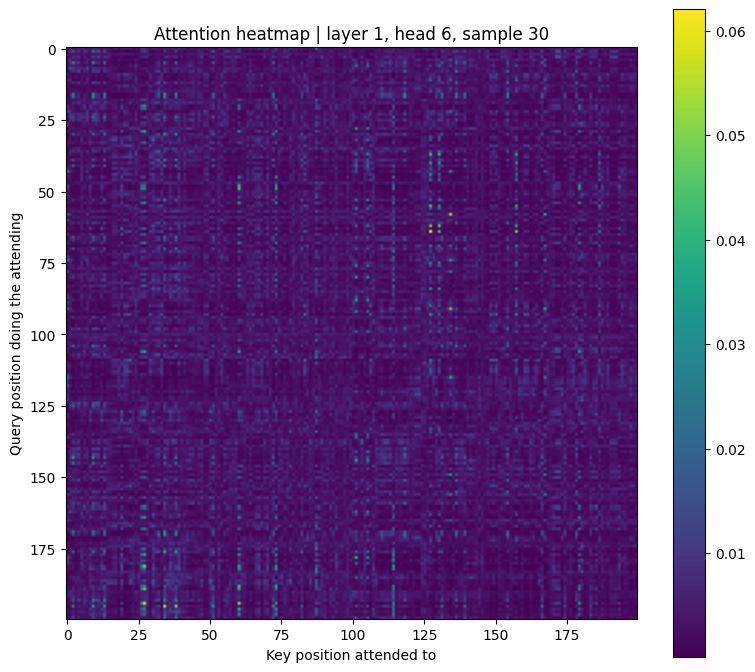

Masked position: 4
Input token at masked position: -
True residue: E
Top-1 prediction: I

Top 10 predicted residues:
  I : 0.1482
  L : 0.1439
  V : 0.1177
  K : 0.0929
  A : 0.0837
  T : 0.0481
  E : 0.0466
  R : 0.0458
  Y : 0.0419
  F : 0.0396

Top 10 attended positions from masked position 4:
  Position  134 | Token  H | Attention 0.0184
  Position  167 | Token  H | Attention 0.0146
  Position  218 | Token  M | Attention 0.0110
  Position  251 | Token  T | Attention 0.0109
  Position  136 | Token  F | Attention 0.0106
  Position  236 | Token  F | Attention 0.0105
  Position  209 | Token  F | Attention 0.0095
  Position  248 | Token  T | Attention 0.0093
  Position  118 | Token  F | Attention 0.0088
  Position  154 | Token  F | Attention 0.0083

Masked position: 11
Input token at masked position: -
True residue: A
Top-1 prediction: A

Top 10 predicted residues:
  A : 0.1500
  G : 0.1475
  T : 0.0947
  D : 0.0821
  S : 0.0746
  N : 0.0733
  K : 0.0547
  L : 0.0511
  V : 0.0409
  E : 

In [102]:
# ==========================
# Observe attention behaviour
# ==========================

import torch
import matplotlib.pyplot as plt

def observe_attention(
    model,
    loader,
    device,
    aa_itos,
    layer_idx=-4,
    head_idx=0,
    sample_idx=200,
    top_k=10,
    max_display_len=200
):
    model.eval()

    with torch.no_grad():
        X_batch, y_batch, attention_mask = next(iter(loader))

        X_batch = X_batch.to(device).long()
        y_batch = y_batch.to(device).long()
        attention_mask = attention_mask.to(device).bool()

        output, attentions = model(
            X_batch,
            attention_mask,
            return_attention=True
        )

    # --------------------------
    # Basic shape checks
    # --------------------------
    print("X_batch shape:", X_batch.shape)
    print("y_batch shape:", y_batch.shape)
    print("attention_mask shape:", attention_mask.shape)
    print("output/logits shape:", output.shape)
    print("number of attention layers returned:", len(attentions))
    print("chosen attention layer shape:", attentions[layer_idx].shape)
    print()

    # --------------------------
    # Select one sample/head/layer
    # --------------------------
    attn = attentions[layer_idx][sample_idx, head_idx].detach().cpu()

    x_sample = X_batch[sample_idx].detach().cpu()
    y_sample = y_batch[sample_idx].detach().cpu()
    mask_sample = attention_mask[sample_idx].detach().cpu()

    real_len = mask_sample.sum().item()

    print(f"Using sample {sample_idx}")
    print(f"Using layer {layer_idx}")
    print(f"Using head {head_idx}")
    print(f"Real sequence length including padding removal: {real_len}")
    print()

    # Trim to real sequence length
    attn_real = attn[:real_len, :real_len]
    x_real = x_sample[:real_len]
    y_real = y_sample[:real_len]

    # --------------------------
    # Print input sequence tokens
    # --------------------------
    tokens = [aa_itos[token_id.item()] for token_id in x_real]

    print("Input tokens:")
    print("".join(tokens[:max_display_len]))

    if real_len > max_display_len:
        print(f"... truncated from {real_len} tokens to {max_display_len}")
    print()

    # --------------------------
    # Find masked positions
    # --------------------------
    masked_positions = torch.where(y_real != -100)[0]

    print("Masked positions:")
    print(masked_positions.tolist())
    print()

    if len(masked_positions) == 0:
        print("No masked positions found in this sample. Try running the cell again or increase masking rate.")
        return

    # --------------------------
    # Plot attention heatmap
    # --------------------------
    display_len = min(real_len, max_display_len)

    plt.figure(figsize=(8, 7))
    plt.imshow(attn_real[:display_len, :display_len])
    plt.colorbar()
    plt.xlabel("Key position attended to")
    plt.ylabel("Query position doing the attending")
    plt.title(f"Attention heatmap | layer {layer_idx}, head {head_idx}, sample {sample_idx}")
    plt.tight_layout()
    plt.show()

    # --------------------------
    # For each masked position, show:
    # 1. true residue
    # 2. predicted residue
    # 3. top predicted residues
    # 4. top attended positions
    # --------------------------
    probs = torch.softmax(output[sample_idx].detach().cpu(), dim=-1)

    for mask_pos in masked_positions[:5]:
        mask_pos = mask_pos.item()

        true_id = y_real[mask_pos].item()
        true_token = aa_itos[true_id]

        pred_probs = probs[mask_pos]
        pred_id = pred_probs.argmax().item()
        pred_token = aa_itos[pred_id]

        top_pred_values, top_pred_ids = torch.topk(pred_probs, k=min(top_k, len(aa_itos)))

        print("=" * 60)
        print(f"Masked position: {mask_pos}")
        print(f"Input token at masked position: {aa_itos[x_real[mask_pos].item()]}")
        print(f"True residue: {true_token}")
        print(f"Top-1 prediction: {pred_token}")
        print()

        print(f"Top {top_k} predicted residues:")
        for value, token_id in zip(top_pred_values, top_pred_ids):
            print(f"  {aa_itos[token_id.item()]} : {value.item():.4f}")

        print()

        # Attention row = what this masked position attends to
        attn_to_position = attn_real[mask_pos]

        top_attn_values, top_attn_positions = torch.topk(
            attn_to_position,
            k=min(top_k, real_len)
        )

        print(f"Top {top_k} attended positions from masked position {mask_pos}:")
        for value, pos in zip(top_attn_values, top_attn_positions):
            pos = pos.item()
            token = aa_itos[x_real[pos].item()]
            print(f"  Position {pos:>4} | Token {token:>2} | Attention {value.item():.4f}")

        print("=" * 60)
        print()


# Run it
observe_attention(
    model=transformer,
    loader=test_loader,
    device=device,
    aa_itos=aa_itos,
    layer_idx=1,      # final encoder layer
    head_idx=6,        # first attention head
    sample_idx=30,      # first protein in batch
    top_k=10,
    max_display_len=200
)